In [1]:
#!/usr/bin/env python3
"""
test_pipeline.py — Verify the full pipeline works using synthetic data.

Run this on any machine (no internet needed) to check that all
dependencies are installed and the code is correct:

    python test_pipeline.py

Then use step1/2/3 on your real machine or DGX where HEASARC is accessible.
"""
import sys, os, json
sys.path.insert(0, '/workspace/FRED_Classification')
os.chdir('/workspace/FRED_Classification')
from download_grb_data import *

os.makedirs('grb_data/fits',  exist_ok=True)
os.makedirs('grb_data/plots', exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.stats import skew

In [2]:
# ── Generate synthetic CTIME FITS files ──────────────────────────────────────
def norris(t, A, tau1, tau2, ts=0):
    out = np.zeros_like(t)
    m = t > ts
    out[m] = A * np.exp(-tau1/(t[m]-ts) - (t[m]-ts)/tau2)
    return out

def make_synthetic_ctime(trigger_name, pulse_type, outdir, seed):
    """Create a realistic fake CTIME FITS file."""
    rng = np.random.default_rng(seed)
    t_edges = np.arange(-60, 201, 0.512)         # CTIME default bin width ~512ms
    trigtime = 400000000.0                         # dummy Fermi MET

    bg   = 280.0
    n    = len(t_edges) - 1
    t    = 0.5 * (t_edges[:-1] + t_edges[1:])
    expo = np.full(n, 0.512)

    if pulse_type == 'fred':
        src = norris(t, A=rng.uniform(150, 350),
                     tau1=rng.uniform(1, 4), tau2=rng.uniform(8, 20))
    elif pulse_type == 'multi':
        n_pk = rng.integers(2, 5)
        src  = sum(norris(t, A=rng.uniform(60, 150),
                          tau1=rng.uniform(1, 5), tau2=rng.uniform(5, 15),
                          ts=rng.uniform(0, 30))
                   for _ in range(n_pk))
    elif pulse_type == 'flat':
        src = rng.uniform(50, 200) * np.ones(n) * ((t > 5) & (t < 50)).astype(float)
    else:
        src = np.zeros(n)

    total_rate = bg + src + rng.normal(0, np.sqrt(bg + src + 1))
    total_rate = np.clip(total_rate, 0, None)
    counts_row = np.round(total_rate * expo).astype(int)

    # Distribute across 8 channels (rough approximation)
    weights = np.array([0.05, 0.12, 0.18, 0.22, 0.20, 0.12, 0.08, 0.03])
    counts  = np.outer(counts_row, weights).astype(int)

    # Build FITS
    col_time  = fits.Column(name='TIME',     format='D', array=t_edges[:-1] + trigtime)
    col_end   = fits.Column(name='ENDTIME',  format='D', array=t_edges[1:]  + trigtime)
    col_cnt   = fits.Column(name='COUNTS',   format='8J', array=counts)
    col_exp   = fits.Column(name='EXPOSURE', format='E', array=expo)
    spec_hdu  = fits.BinTableHDU.from_columns(
        fits.ColDefs([col_time, col_end, col_cnt, col_exp]),
        name='SPECTRUM'
    )
    phdr = fits.PrimaryHDU()
    phdr.header['TRIGTIME'] = trigtime

    fpath = os.path.join(outdir, 'fits', f'ctime_{trigger_name}_n0.pha')
    fits.HDUList([phdr, spec_hdu]).writeto(fpath, overwrite=True)
    return fpath


# ── Create synthetic dataset (20 FRED, 15 multi-peak, 5 flat) ────────────────
print("Generating synthetic lightcurve dataset...")
manifest, labels = [], {}
types = (
    [('fred', 1)]  * 20 +
    [('multi', 0)] * 15 +
    [('flat',  0)] *  5
)

for i, (ptype, lbl) in enumerate(types):
    trig = f'bn_synth_{ptype}_{i:03d}'
    fpath = make_synthetic_ctime(trig, ptype, 'grb_data', seed=i*13+7)
    t90   = 40.0 if ptype == 'fred' else 55.0

    manifest.append({'trigger_name': trig, 'fits': fpath,
                     'png': '', 't90': t90, 'det': 'n0'})
    labels[trig] = lbl

print(f"  Created {len(manifest)} synthetic bursts "
      f"(FRED={sum(v for v in labels.values())}, "
      f"non-FRED={sum(1-v for v in labels.values())})")

with open('grb_data/manifest.json', 'w') as f:
    json.dump(manifest, f, indent=2)
with open('grb_data/labels.json', 'w') as f:
    json.dump(labels, f, indent=2)


# ── Run feature extraction ────────────────────────────────────────────────────
print("\nExtracting features...")
from step2_features_label import extract_all_features
df = extract_all_features(manifest, labels)
print(f"  Features extracted: {len(df)} rows, {len(df.columns)} columns")


# ── Run training ──────────────────────────────────────────────────────────────
print("\nTraining classifier...")
from step3_train import load_dataset, train_and_evaluate
X, y, names, df2 = load_dataset()
model = train_and_evaluate(X, y, names, df2)

print("\n" + "═"*55)
print("  PIPELINE TEST PASSED")
print("  All components work correctly.")
print("═"*55)
print("\nOutput files:")
for f in ['grb_data/features.csv', 'grb_data/predictions.csv',
          'grb_data/fred_classifier.pkl', 'grb_data/classifier_results.png']:
    size = os.path.getsize(f) if os.path.exists(f) else 0
    print(f"  {f}  ({size/1024:.1f} KB)")
print("\nNext steps (on your MacBook or DGX where HEASARC is reachable):")
print("  1. python step1_download.py    # downloads ~50 real GRB lightcurves")
print("  2. python step2_features_label.py  # label + extract features")
print("  3. python step3_train.py       # train and evaluate classifier")


Generating synthetic lightcurve dataset...
  Created 40 synthetic bursts (FRED=20, non-FRED=20)

Extracting features...

Features extracted for 40 bursts  (0 failed)
Saved → grb_data/features.csv

Class balance:
label
FRED        20
non-FRED    20
Name: count, dtype: int64
  Features extracted: 40 rows, 11 columns

Training classifier...
Dataset: 40 bursts
  FRED     : 20
  non-FRED : 20

── 5-fold stratified cross-validation ─────────────────
  Random Forest              F1 = 0.978 ± 0.044
  Logistic Regression        F1 = 0.978 ± 0.044

→ Best model: Random Forest

── Classification report (resubstitution on full training set) ──
              precision    recall  f1-score   support

    non-FRED      1.000     1.000     1.000        20
        FRED      1.000     1.000     1.000        20

    accuracy                          1.000        40
   macro avg      1.000     1.000     1.000        40
weighted avg      1.000     1.000     1.000        40

Saved evaluation plot → grb_data/

In [3]:
# Cell 1 — fetch catalog
cat = fetch_catalog()

Sending request and awaiting response from HEASARC...
Finished in 255 s
  → <BurstCatalog: 306 columns, 4335 rows>


In [4]:
import importlib, download_grb_data
importlib.reload(download_grb_data)
from download_grb_data import *

table = filter_long_grbs(cat, min_t90=2.0)

  Available columns (first 20): ('NAME', 'RA', 'DEC', 'TRIGGER_TIME', 'T90', 'T90_ERROR', 'T90_START', 'FLUENCE', 'FLUENCE_ERROR', 'FLUX_1024', 'FLUX_1024_ERROR', 'FLUX_1024_TIME', 'FLUX_64', 'FLUX_64_ERROR', 'FLNC_BAND_AMPL', 'FLNC_BAND_AMPL_POS_ERR', 'FLNC_BAND_AMPL_NEG_ERR', 'FLNC_BAND_EPEAK', 'FLNC_BAND_EPEAK_POS_ERR', 'FLNC_BAND_EPEAK_NEG_ERR')
  → 3609 long GRBs (T90 > 2.0s) out of 4335 total


In [5]:
results = download_all(table, n_bursts=20, outdir=OUTDIR)

/usr/local/lib/python3.12/site-packages/gdt/core/heasarc.py:257: UserWarning: FTP access to heasarc.gsfc.nasa.gov is unreliable due to high server loads. Users should switch to HTTPS access.
  warnings.warn(


Output()

Output()

Output()

Output()

...

Output()

Output()

Output()

Output()

  ✓ GRB200607921  (14 files)

Downloaded 20 bursts → /workspace/data/grb_data/fits/


In [7]:
import ipywidgets as widgets
from IPython.display import display
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

LABELS_PATH = f'{OUTDIR}/labels.csv'

# Build df from download_all results (run once)
df = pd.DataFrame(results)   # columns: trigger_name, t90, files

def load_existing_labels():
    if os.path.exists(LABELS_PATH):
        return pd.read_csv(LABELS_PATH).set_index('trigger_name')['label'].to_dict()
    return {}

def save_label(trigger_name, label):
    labels = load_existing_labels()
    labels[trigger_name] = label
    pd.DataFrame(list(labels.items()), columns=['trigger_name', 'label']).to_csv(LABELS_PATH, index=False)

def get_ctime_lightcurve(trigger_name, files, fits_dir=f'{OUTDIR}/fits', half_window=60):
    """Sum CTIME counts across detectors/energy channels, windowed around trigger time."""
    all_t, all_c = [], []
    for fname in files:
        path = os.path.join(fits_dir, fname)
        with fits.open(path) as hdul:
            trigtime = hdul[0].header.get('TRIGTIME', 0.0)
            data = hdul['SPECTRUM'].data
            t = data['TIME'] - trigtime
            c = data['COUNTS'].sum(axis=1)
            mask = np.abs(t) < half_window
            all_t.append(t[mask]); all_c.append(c[mask])
    if not all_t:
        return None, None
    t = all_t[0]
    total = np.zeros_like(t, dtype=float)
    for tt, cc in zip(all_t, all_c):
        n = min(len(t), len(cc))
        total[:n] += cc[:n]
    return t, total

def show_page(df, page=0, page_size=9):
    labels = load_existing_labels()
    subset = df.iloc[page*page_size : page*page_size + page_size]

    for _, row in subset.iterrows():
        trig = row['trigger_name']
        out = widgets.Output()
        with out:
            t, counts = get_ctime_lightcurve(trig, row['files'])
            fig, ax = plt.subplots(figsize=(4, 2.5))
            if t is not None:
                ax.plot(t, counts, lw=0.8)
            ax.set_title(f"{trig}  (T90={row['t90']:.1f}s)", fontsize=9)
            ax.set_xlabel('t - t_trig (s)')
            plt.tight_layout()
            plt.show()

        dropdown = widgets.Dropdown(
            options=['unlabeled', 'FRED', 'not-FRED', 'unclear'],
            value=labels.get(trig, 'unlabeled'),
            description='Label:'
        )

        def on_change(change, trig=trig):
            if change['name'] == 'value':
                save_label(trig, change['new'])

        dropdown.observe(on_change, names='value')
        display(widgets.VBox([out, dropdown]))

    n_pages = (len(df) - 1) // page_size + 1
    print(f"Page {page+1} of {n_pages}. Call show_page(df, page={page+1}) for the next batch.")

In [8]:
# Cell 3 — browse and label
show_page(df, page=0)   # shows 9 at a time, repeat with page=1, 2, ...

Page 1 of 3. Call show_page(df, page=1) for the next batch.


In [11]:
import ipywidgets as widgets
from IPython.display import display
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

LABELS_PATH = f'{OUTDIR}/labels.csv'
PLOTS_DIR = f'{OUTDIR}/plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

# Build df from download_all results (run once)
df = pd.DataFrame(results)   # columns: trigger_name, t90, files


def load_existing_labels():
    if os.path.exists(LABELS_PATH):
        return pd.read_csv(LABELS_PATH).set_index('trigger_name')['label'].to_dict()
    return {}


def save_label(trigger_name, label):
    labels = load_existing_labels()
    labels[trigger_name] = label
    pd.DataFrame(list(labels.items()), columns=['trigger_name', 'label']).to_csv(LABELS_PATH, index=False)


def get_ctime_lightcurve(trigger_name, files, fits_dir=f'{OUTDIR}/fits', half_window=60):
    """Sum CTIME counts across detectors/energy channels, windowed around trigger time."""
    all_t, all_c = [], []
    for fname in files:
        path = os.path.join(fits_dir, fname)
        with fits.open(path) as hdul:
            trigtime = hdul[0].header.get('TRIGTIME', 0.0)
            data = hdul['SPECTRUM'].data
            t = data['TIME'] - trigtime
            c = data['COUNTS'].sum(axis=1)
            mask = np.abs(t) < half_window
            all_t.append(t[mask]); all_c.append(c[mask])
    if not all_t:
        return None, None
    t = all_t[0]
    total = np.zeros_like(t, dtype=float)
    for tt, cc in zip(all_t, all_c):
        n = min(len(t), len(cc))
        total[:n] += cc[:n]
    return t, total


def show_page(df, page=0, page_size=9):
    labels = load_existing_labels()
    subset = df.iloc[page*page_size : page*page_size + page_size]

    for _, row in subset.iterrows():
        trig = row['trigger_name']
        out = widgets.Output()
        with out:
            t, counts = get_ctime_lightcurve(trig, row['files'])
            fig, ax = plt.subplots(figsize=(4, 2.5))
            if t is not None:
                ax.plot(t, counts, lw=0.8)
            ax.set_title(f"{trig}  (T90={row['t90']:.1f}s)", fontsize=9)
            ax.set_xlabel('t - t_trig (s)')
            plt.tight_layout()

            # save before showing
            fig.savefig(f'{PLOTS_DIR}/{trig}.png', dpi=100)

            # save raw arrays too — more useful for ML than the PNG itself
            if t is not None:
                np.savez(f'{PLOTS_DIR}/{trig}_lc.npz', time=t, counts=counts)

            plt.show()

        dropdown = widgets.Dropdown(
            options=['unlabeled', 'FRED', 'not-FRED', 'unclear'],
            value=labels.get(trig, 'unlabeled'),
            description='Label:'
        )

        def on_change(change, trig=trig):
            if change['name'] == 'value':
                save_label(trig, change['new'])

        dropdown.observe(on_change, names='value')
        display(widgets.VBox([out, dropdown]))

    n_pages = (len(df) - 1) // page_size + 1
    print(f"Page {page+1} of {n_pages}. Call show_page(df, page={page+1}) for the next batch.")

In [12]:
os.listdir(PLOTS_DIR)

['bn080804972_lc.png',
 'bn080730786_lc.png',
 'bn080723985_lc.png',
 'bn080806584_lc.png',
 'bn080725435_lc.png',
 'bn080724401_lc.png',
 'bn080806896_lc.png',
 'bn080804456_lc.png',
 'bn080717543_lc.png',
 'bn080714086_lc.png',
 'bn080808772_lc.png',
 'bn080723557_lc.png',
 'bn080719529_lc.png',
 'bn080803772_lc.png',
 'bn080730520_lc.png',
 'bn080714745_lc.png',
 'bn080714425_lc.png',
 'bn080727964_lc.png',
 'bn080805584_lc.png',
 'bn080809808_lc.png',
 'bn080808565_lc.png',
 'bn080805496_lc.png',
 'bn080807993_lc.png',
 'bn080810549_lc.png',
 'bn080808451_lc.png',
 'bn080715950_lc.png',
 'bn080812889_lc.png']

In [13]:
[f for f in os.listdir(PLOTS_DIR) if f.endswith('.npz')]

[]

In [18]:
!cd /workspace/data/grb_data/plots ls -lh *.npz


In [19]:
sample_file = os.listdir(f'{OUTDIR}/fits')[0]
with fits.open(f'{OUTDIR}/fits/{sample_file}') as hdul:
    hdul.info()
    print(hdul[0].header.get('TRIGTIME'))

Filename: /workspace/data/grb_data/fits/glg_ctime_n1_bn120403857_v00.pha
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      37   ()      
  1  EBOUNDS       1 BinTableHDU     58   8R x 3C   [1I, 1E, 1E]   
  2  SPECTRUM      1 BinTableHDU     72   14824R x 5C   [8I, 1E, 1I, 1D, 1D]   
  3  GTI           1 BinTableHDU     44   1R x 2C   [1D, 1D]   
355178040.49309


In [21]:
# 1. Does df's 'files' column actually have entries?
print(df[['trigger_name', 'files']].head(10))

# 2. Pick one row and call the function directly (exceptions will surface here, unhidden)
row = df.iloc[0]
print(row['trigger_name'], row['files'])
t, counts = get_ctime_lightcurve(row['trigger_name'], row['files'])
print(t is None, counts if counts is None else len(counts))

   trigger_name                                              files
0  GRB120403857  [glg_ctime_n1_bn120403857_v00.pha, glg_ctime_n...
1  GRB120227725  [glg_ctime_b1_bn120227725_v00.pha, glg_ctime_b...
2  GRB230524357  [glg_ctime_n7_bn230524357_v00.pha, glg_ctime_n...
3  GRB141205018  [glg_ctime_b0_bn141205018_v00.pha, glg_ctime_b...
4  GRB180630467  [glg_ctime_b0_bn180630467_v00.pha, glg_ctime_b...
5  GRB170116238  [glg_ctime_b0_bn170116238_v00.pha, glg_ctime_b...
6  GRB250330255  [glg_ctime_n6_bn250330255_v00.pha, glg_ctime_n...
7  GRB250926827  [glg_ctime_n8_bn250926827_v00.pha, glg_ctime_n...
8  GRB091026550  [glg_ctime_n9_bn091026550_v00.pha, glg_ctime_n...
9  GRB230428381  [glg_ctime_n9_bn230428381_v00.pha, glg_ctime_n...
GRB120403857 ['glg_ctime_n1_bn120403857_v00.pha', 'glg_ctime_n0_bn120403857_v00.pha', 'glg_ctime_n3_bn120403857_v00.pha', 'glg_ctime_n2_bn120403857_v00.pha', 'glg_ctime_n4_bn120403857_v00.pha', 'glg_ctime_n5_bn120403857_v00.pha', 'glg_ctime_n6_bn120403857_v00.pha

In [22]:
t, counts = get_ctime_lightcurve(row['trigger_name'], row['files'])
np.savez(f'{PLOTS_DIR}/test_isolated.npz', time=t, counts=counts)
print(glob.glob(f'{PLOTS_DIR}/test_isolated.npz'))

['/workspace/data/grb_data/plots/test_isolated.npz']


In [28]:
def get_ctime_lightcurve(trigger_name, files, fits_dir=f'{OUTDIR}/fits', half_window=60):
    all_t, all_rate = [], []
    for fname in files:
        path = os.path.join(fits_dir, fname)
        with fits.open(path) as hdul:
            trigtime = hdul[0].header.get('TRIGTIME', 0.0)
            data = hdul['SPECTRUM'].data
            t = data['TIME'] - trigtime
            counts = data['COUNTS'].sum(axis=1)
            exposure = data['EXPOSURE']
            rate = counts / exposure          # <-- counts/s, bin-width independent
            mask = np.abs(t) < half_window
            all_t.append(t[mask]); all_rate.append(rate[mask])
    if not all_t:
        return None, None
    t = all_t[0]
    total = np.zeros_like(t, dtype=float)
    for tt, rr in zip(all_t, all_rate):
        n = min(len(t), len(rr))
        total[:n] += rr[:n]
    return t, total

In [29]:
df = pd.DataFrame(results)   # make sure this reflects the batch you want
show_page(df, page=0)

Page 1 of 3. Call show_page(df, page=1) for the next batch.


In [24]:
glob.glob(f'{PLOTS_DIR}/*.npz')

['/workspace/data/grb_data/plots/test_isolated.npz',
 '/workspace/data/grb_data/plots/GRB170116238_lc.npz',
 '/workspace/data/grb_data/plots/GRB250330255_lc.npz',
 '/workspace/data/grb_data/plots/GRB180630467_lc.npz',
 '/workspace/data/grb_data/plots/GRB120227725_lc.npz',
 '/workspace/data/grb_data/plots/GRB250926827_lc.npz',
 '/workspace/data/grb_data/plots/GRB120403857_lc.npz',
 '/workspace/data/grb_data/plots/GRB091026550_lc.npz',
 '/workspace/data/grb_data/plots/GRB230524357_lc.npz',
 '/workspace/data/grb_data/plots/GRB141205018_lc.npz']

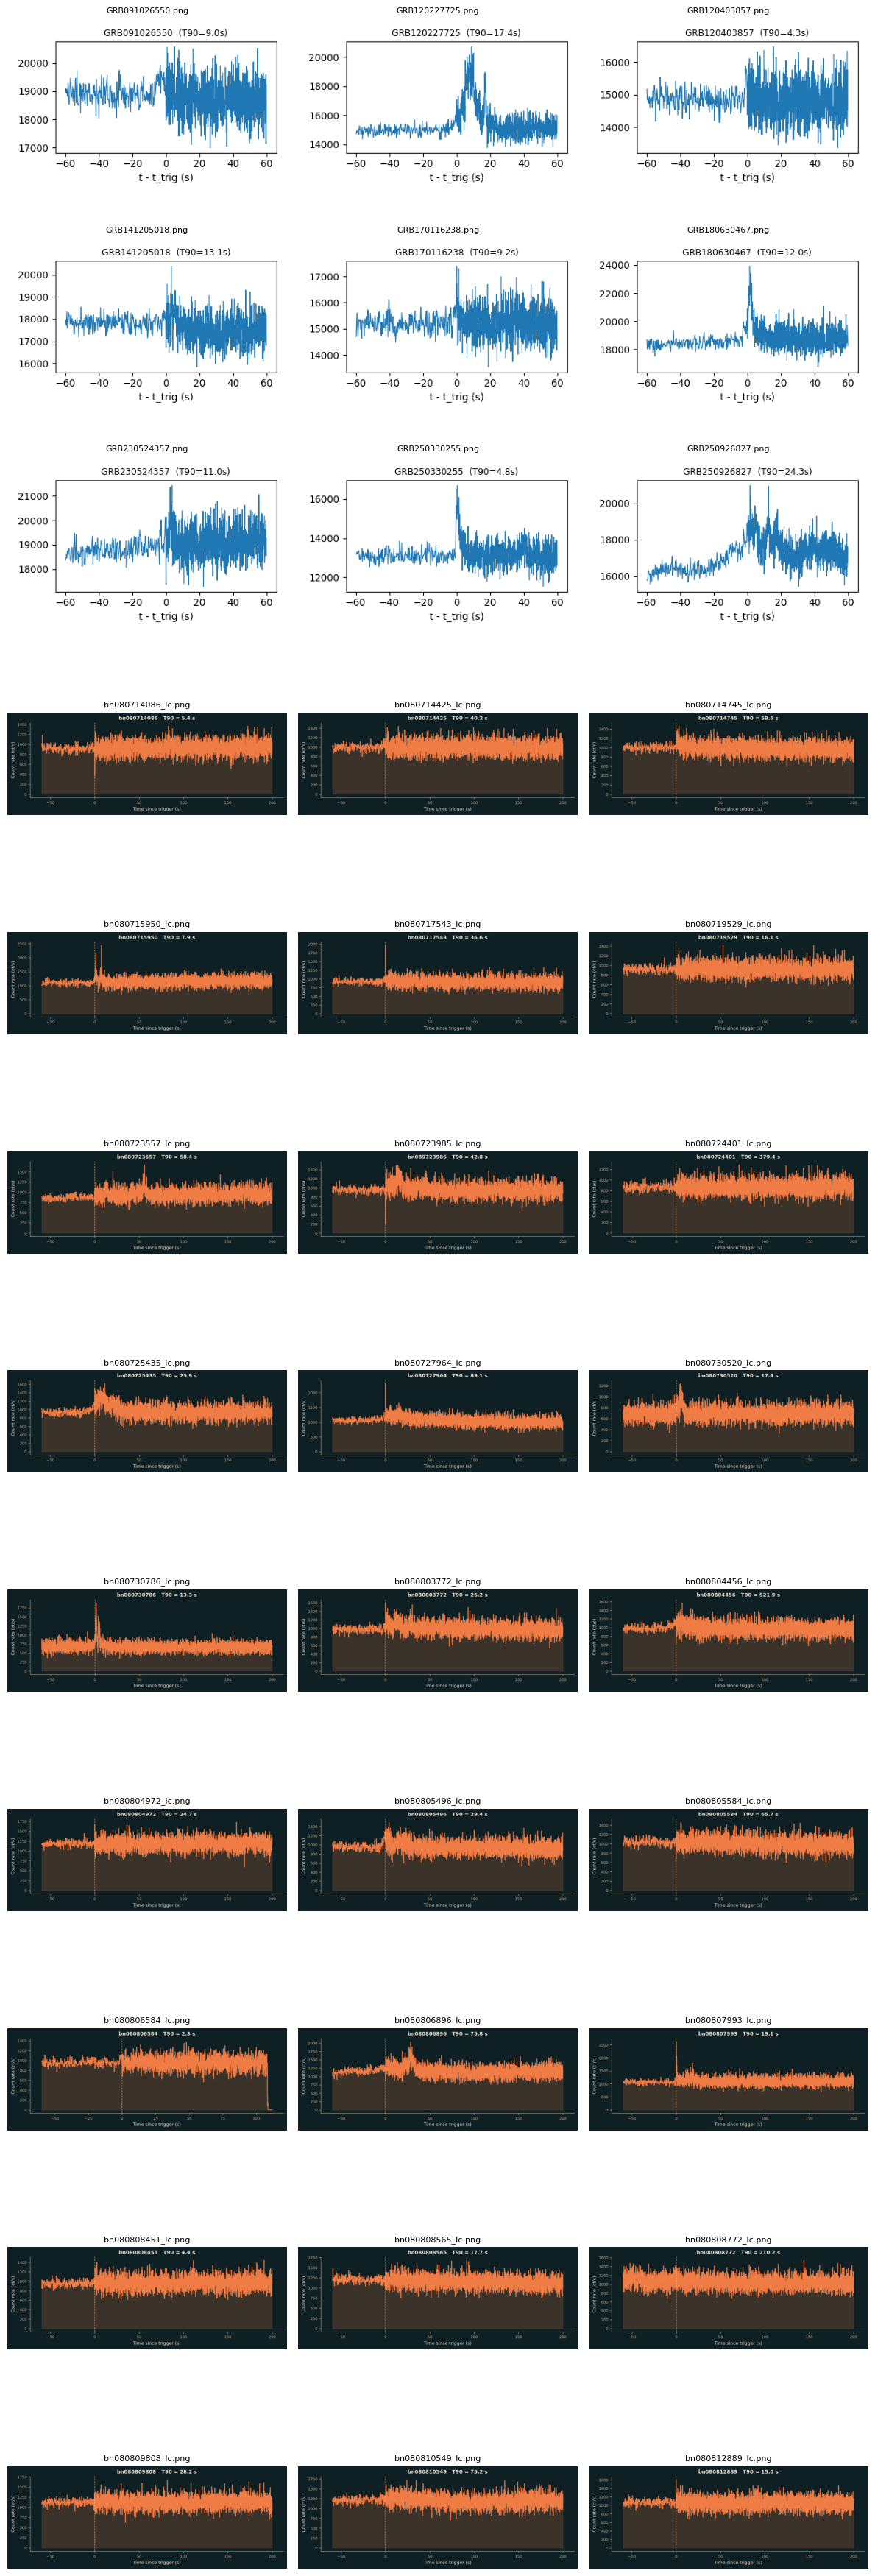

In [30]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob

files = sorted(glob.glob(f'{PLOTS_DIR}/*.png'))
n = len(files)
cols = 3
rows = (n - 1) // cols + 1

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
axes = axes.flatten()
for ax, f in zip(axes, files):
    img = mpimg.imread(f)
    ax.imshow(img)
    ax.set_title(f.split('/')[-1], fontsize=8)
    ax.axis('off')
for ax in axes[len(files):]:
    ax.axis('off')
plt.tight_layout()
plt.show()